---
title: Utilize post-selection in workloads
description: Understand how to integrate post-selection as part of your error mitigation strategy
---

# Utilize post-selection in workloads

When optimizing a workload's error mitigation strategy, it is often useful to filter out measurements which are known to have been contaminated by non-Markovian (i.e. correlated) noise processes. One such method for doing so involves appending a circuit with a post-processing step that measures active and adjacent "spectator" qubits, applies a slow rotation to each qubit, then measures them again. In instances where the two measurements do not confirm a flipped qubit as expected, the shot is discarded by applying a mask to the results. 

The [utilities addon](https://qiskit.github.io/qiskit-addon-utils/) provides a set of transpiler passes and a post selection function to apply the mask. This page provides guidance on how to incorporate post-selection into your quantum workloads by using a 4 qubit GHZ state as an example.

## Create workload 

First start by preparing the circuit to execute and transpile it against a backend which supports fractional gates

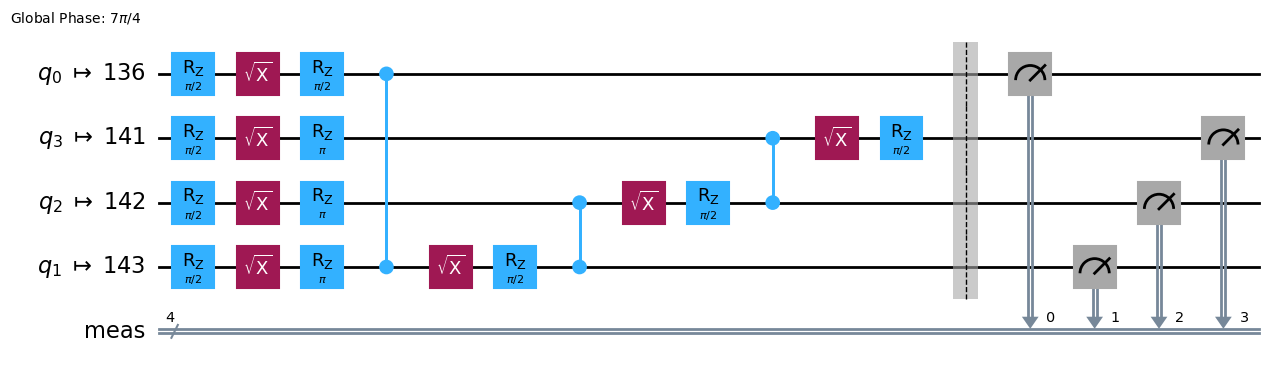

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager

circuit = QuantumCircuit(4)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(1,2)
circuit.cx(2,3)
circuit.measure_all()


service = QiskitRuntimeService()
backend = service.least_busy(use_fractional_gates=True)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

transpiled_circuit = pm.run(circuit)
transpiled_circuit.draw('mpl')

## Add post-selection transpiler passes

Then create a preset pass manager which includes the [`AddPostSelectionMeasures`](https://qiskit.github.io/qiskit-addon-utils/stubs/qiskit_addon_utils.noise_management.post_selection.transpiler.passes.AddSpectatorMeasures.html) and [`AddSpectatorMeasures`](https://qiskit.github.io/qiskit-addon-utils/stubs/qiskit_addon_utils.noise_management.post_selection.transpiler.passes.AddPostSelectionMeasures.html) passes from the [`qiskit-addon-utils`](https://qiskit.github.io/qiskit-addon-utils/index.html) package.

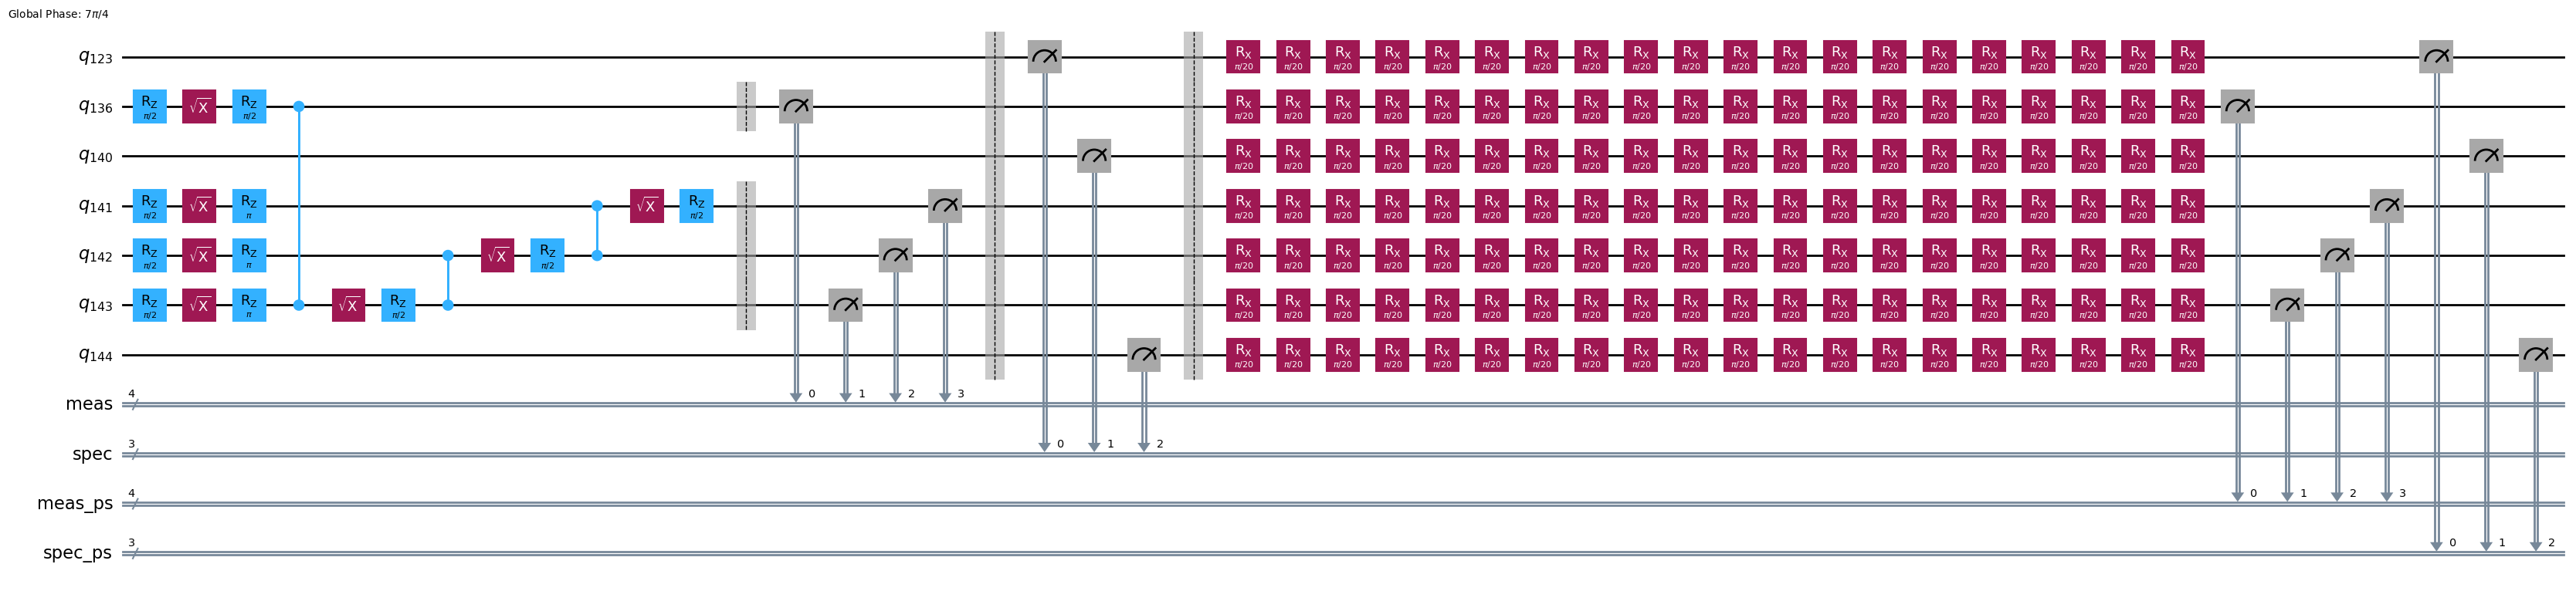

In [2]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.post_selection import PostSelector
from qiskit_addon_utils.noise_management.post_selection.transpiler.passes import AddPostSelectionMeasures, AddSpectatorMeasures
from samplomatic import build


post_selection_pm = PassManager(
    [
        AddSpectatorMeasures(backend.coupling_map, add_barrier=True),
        AddPostSelectionMeasures(x_pulse_type="rx"),
    ]
)


#template_circuit, samplex = build(transpiled_circuit)
template_circuit_ps = post_selection_pm.run(transpiled_circuit)
template_circuit_ps.draw('mpl', fold=-1, idle_wires=False)

## Execute quantum program

Next we prepare a `QuantumProgram` object containing the samplex and the circuit to be executed.

In [3]:
from qiskit_ibm_runtime import QuantumProgram, Executor

shots_per_randomization = 40
shape = 100
shots = 4000

program = QuantumProgram(shots=shots)
program.append_circuit_item(template_circuit_ps)
# program.append_samplex_item(
#     template_circuit_ps,
#     samplex=samplex,
#     shape=(shape,)
# )


# Initialize the Executor job and run
executor = Executor(backend)
executor_job = executor.run(program)
print(f'Job ID: {executor_job.job_id()}')

Job ID: d7faktq1u7fs739lpd2g


Then interpret the results. The executor result is a dictionary with several keys.

In [4]:
executor_result = executor_job.result()[0]
executor_result.keys()

dict_keys(['meas', 'spec', 'meas_ps', 'spec_ps'])

These keys correspond to the active and spectator qubits before the `rx` instructions (`meas` and `spec`) and after the `rx` instructions (`meas_ps` and `spec_ps`). Each of these will be an array of arrays based on the number of shots, randomizations, and qubits. So in this case the shape will be (1000, 4).


## Create post-selection mask

From these measurements, we can create a mask using the `PostSelector` class from `qiskit-addon-utils`. This mask is a boolean array where each shot is marked as either `True` or `False` based on one of two post selection strategies. This first, `node`, uses qubit information to decide whether a measurement shot should be discarded and the second, `edge`, uses nearest neighbor connectivity information to make this decision.

In [5]:
from qiskit_addon_utils.noise_management.post_selection import PostSelector

post_selector = PostSelector.from_circuit(
        circuit=template_circuit_ps, coupling_map=backend.coupling_map
    )

mask_node = post_selector.compute_mask(executor_result, strategy="node")
mask_edge = post_selector.compute_mask(executor_result, strategy="edge")

The node and the edge strategy often discards different shots. One can choose to select any of them. Or, in this notebook we shall take a bitwise AND. This, then, becomes a conservative strategy where we retain a shot only if it is passed by both node and edge strategies.

In [6]:
mask = mask_node & mask_edge
print(f'The combined mask for first twirl instance: {mask[0]}')
count_retained = 0

for m in mask:
    count_retained += m

print(f'Percentage of the shots retained is after post selection {100 * count_retained / shots}')

The combined mask for first twirl instance: True
Percentage of the shots retained is after post selection 80.85


Next let's compare the probability distribution with and without post selection. The following snippet computes the probability distribution before and after post-selection and computes the distance between the measured and ideal distributions.

In [ ]:
counts = {}
counts_ps = {}


for idx, measurement in enumerate(executor_result['meas']):
    bitstring = ''
    for bit in measurement:
        bitstring += str(int(bit))

    if bitstring in counts:
        counts[bitstring] += 1
    else:
        counts[bitstring] = 1

    # Compute count data for post-selected shots based on the mask
    if mask[idx]:
        bitstring = ''
        for bit in measurement:
            bitstring += str(int(bit))

        if bitstring in counts_ps:
            counts_ps[bitstring] += 1
        else:
            counts_ps[bitstring] = 1

for key, val in counts.items():
    counts[key] = val/shots


for key, val in counts_ps.items():
    counts_ps[key] = float(val/count_retained)


To demonstrate how the post-selection changed our results, we can then compute the distance between the ideal probability distribution and the measured ones.

In [ ]:
import itertools
bitstrings = [''.join(i) for i in itertools.product('01', repeat=4)]
counts_ideal = {}
for bitstring in bitstrings:
    counts_ideal[bitstring] = 0.
counts_ideal['1111'] = 0.5
counts_ideal['0000'] = 0.5


prob_distance = 0.
prob_distance_ps = 0.

for bitstring in counts_ideal.keys():
    dist = 0.
    dist_ps = 0.
    if bitstring in counts:
        dist = abs(counts[bitstring] - counts_ideal[bitstring])
    if bitstring in counts_ps:
        dist_ps = abs(counts_ps[bitstring] - counts_ideal[bitstring])
    prob_distance += dist
    prob_distance_ps += dist_ps


    

print(f'Distance from ideal distribution before post-selection: {1-prob_distance*0.5}')
print(f'Distance from ideal distribution before after-selection: {1-prob_distance_ps*0.5}')

Distance before post-selection: 0.94225
Distance before after-selection: 0.935374149659864


While post-selection can significantly improve result quality by filtering out outcomes measurements that were affected by non-Markovian noise, it is not a complete solution to error mitigation on its own. Post-selection reduces the impact of certain errors by discarding invalid measurement results, but this comes at the cost of increased sampling overhead and does not address all error mechanisms present in near-term quantum hardware. As a result, relying solely on post-selection may be insufficient for more complex or deeper circuits. Instead, post-selection is most effective when used as part of a broader error mitigation strategy—complementing techniques such as measurement error mitigation, noise-aware circuit compilation, or probabilistic error cancellation—to improve the reliability of quantum workloads while balancing accuracy and resource cost.

## Next steps

<Admonition type="tip" title="Recommendations">
  - Understand how to incorporate [noise learning](./noise-learning) into a quantum workload
  - Read through other available [error mitigation and suppression](./error-mitigation-and-suppression-techniques) techniques
</Admonition>